## Support Vector Classifier Implementation using SKLEARN

In [20]:
1+1

2

In [21]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
## Create a Synthetic Dataset
from sklearn.datasets import make_classification
X,y=make_classification(n_samples=10000, n_features=2,n_classes=2, n_informative=2, n_redundant=0, n_clusters_per_class=2, random_state=42)


In [23]:
pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])


,Feature_1,Feature_2
0,0.771440,-1.262335
1,-1.292116,-0.409111
2,-1.427221,1.619316
3,-1.862943,1.682255
4,1.326361,0.320554
...,...,...
9995,1.213182,-0.644499
9996,1.286575,-0.344466
9997,1.042752,-1.330128
9998,-0.907589,0.858818


In [24]:
y

array([0, 0, 1, ..., 1, 1, 0])

<Axes: >

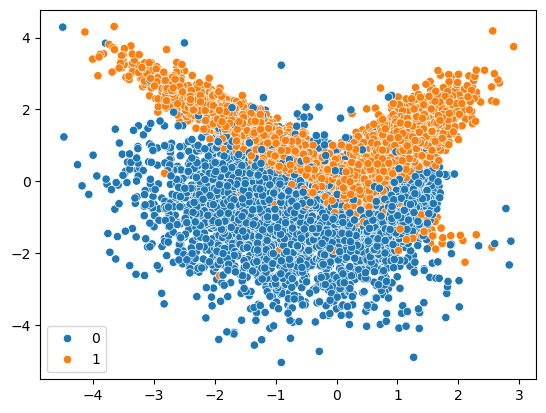

In [25]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)

In [26]:
from sklearn.svm import SVC

In [27]:
svc=SVC(kernel='linear')

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
svc.fit(X_train, y_train)

SVC(kernel='linear')

In [30]:
y_pred=svc.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)
print(confusion_matrix(y_test, y_pred))
# plt.figure(figsize=(10,6))
# sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
# plt.xlabel('Predicted')

              precision    recall  f1-score   support

           0       0.88      0.90      0.89      1007
           1       0.90      0.87      0.88       993

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

[[906 101]
 [126 867]]


In [34]:
# Kernal=rbf
svc1=SVC(kernel='rbf')
svc1.fit(X_train, y_train)
y_pred1=svc1.predict(X_test)
accuracy_score(y_test, y_pred1)
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      1007
           1       0.92      0.93      0.93       993

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



In [35]:
# Kernal=polynomial
svc2=SVC(kernel='poly')
svc2.fit(X_train, y_train)
y_pred2=svc2.predict(X_test)
accuracy_score(y_test, y_pred2)
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.81      0.90      0.85      1007
           1       0.89      0.78      0.83       993

    accuracy                           0.84      2000
   macro avg       0.85      0.84      0.84      2000
weighted avg       0.85      0.84      0.84      2000



In [37]:
# Kernal=sigmoid
svc3=SVC(kernel='sigmoid')
svc3.fit(X_train, y_train)
y_pred3=svc3.predict(X_test)
accuracy_score(y_test, y_pred3)
print(classification_report(y_test, y_pred3))

              precision    recall  f1-score   support

           0       0.80      0.83      0.82      1007
           1       0.82      0.79      0.80       993

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000



### Hyperparameter Tuning of SVC Model

In [38]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid']
}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2)
grid.fit(X_train, y_train)
grid.best_params_
grid_predictions = grid.predict(X_test)
print(classification_report(y_test, grid_predictions))


Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.5s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.5s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.4s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.3s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.3s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.8s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.9s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   1.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.8s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.9s
[CV] END .....................C=0.1, gamma=1, kernel=sigmoid; total time=   0.8s
[CV] END .....................C=0.1, gamma=1, k